# Spinning Box

Here is a basic example of building a simulation using newton.

In [1]:
import matplotlib.pyplot as plt
import newton
import numpy as np
import warp as wp
from lwmr.utils import RECORDING_BASE_PATH, create_viewer_viser
from tqdm.auto import trange

# Tell warp to be quiet before initializing a model
wp.config.quiet = True

/Users/ajcd2020/Documents/Repositories/anthonyjclark/simer-tutorial/2026-icra/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Visualization timing
FRAME_STEP = 1.0 / 60.0

# Simulation timing relative to visualization
SIM_SUBSTEPS = 4
TIME_STEP = FRAME_STEP / SIM_SUBSTEPS

In [3]:
# Build a model
builder = newton.ModelBuilder()
body = builder.add_body()
builder.add_shape_box(body)
builder.add_ground_plane()
model = builder.finalize()

In [4]:
# Allocate state and create a solver
state_0 = model.state()
state_1 = model.state()
control = model.control()
contacts = model.contacts()
solver = newton.solvers.SolverMuJoCo(model)

In [5]:
# Step the simulation
for step in trange(1000):
    state_0.clear_forces()
    model.collide(state_0, contacts)
    solver.step(state_0, state_1, control, contacts, TIME_STEP)
    state_0, state_1 = state_1, state_0

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 1/1000 [00:00<05:49,  2.86it/s]

  6%|▋         | 63/1000 [00:00<00:05, 181.21it/s]

 12%|█▏        | 123/1000 [00:00<00:02, 303.34it/s]

 19%|█▊        | 186/1000 [00:00<00:02, 397.94it/s]

...

 81%|████████  | 808/1000 [00:01<00:00, 601.99it/s]

 87%|████████▋ | 871/1000 [00:01<00:00, 607.87it/s]

 93%|█████████▎| 933/1000 [00:01<00:00, 608.87it/s]

100%|█████████▉| 996/1000 [00:01<00:00, 613.73it/s]

100%|██████████| 1000/1000 [00:01<00:00, 505.96it/s]

## Visualization

We'll use the built-in support for the viser visualizer in newton.

In [6]:
sim_time = 0.0

rec_path = str(RECORDING_BASE_PATH / "cube.viser")
viewer = newton.viewer.ViewerViser(verbose=False, record_to_viser=rec_path)
viewer.set_model(model)

while sim_time < 4.0:
    viewer.begin_frame(sim_time)
    viewer.log_state(state_0)
    viewer.end_frame()
    sim_time += FRAME_STEP

# NOTE: this does not work in VSCode
viewer.show_notebook()

╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

## Visualize a Spinning Cube

`add_body()` calls `add_link()`, `add_joint_free()`, and `add_articulation()`

In [7]:
builder = newton.ModelBuilder()
builder.add_ground_plane()

# Revolute body
xform = wp.transform(p=wp.vec3(0.0, -1.0, 1.0))
body = builder.add_link()
joint = builder.add_joint_revolute(parent=-1, child=body, parent_xform=xform, axis=wp.vec3(0.0, 0.0, 1.0))
builder.add_articulation([joint])
builder.add_shape_box(body)

# Just a single DOF for a revolute joint
joint_index = builder.joint_q_start[joint]
joint_dim = builder.joint_dof_dim[joint_index]
assert joint_dim[0] == 0 and joint_dim[1] == 1
builder.joint_q[joint_index] = 0.5

joint_index = builder.joint_qd_start[joint]
joint_dim = builder.joint_dof_dim[joint_index]
assert joint_dim[0] == 0 and joint_dim[1] == 1
builder.joint_qd[joint_index] = 10.0

# Free body
xform = wp.transform(p=wp.vec3(0.0, 1.0, 1.0))
body = builder.add_body(xform=xform)
builder.add_shape_box(body)

joint_index = builder.joint_q_start[joint] + 1
joint_dim = builder.joint_dof_dim[joint_index]
assert joint_dim[0] == 3 and joint_dim[1] == 3
# builder.joint_q[joint_index + 2] = 0.5

joint_index = builder.joint_qd_start[joint] + 1
joint_dim = builder.joint_dof_dim[joint_index]
assert joint_dim[0] == 3 and joint_dim[1] == 3
builder.joint_qd[joint_index + 5] = 10.0

model = builder.finalize()

state_0 = model.state()
state_1 = model.state()
control = model.control()
contacts = model.contacts()

solver = newton.solvers.SolverMuJoCo(model)

sim_time = 0.0

viewer = create_viewer_viser("spinning_cube", model, quiet=False, overwrite=False)

for step in trange(200):
    for substep in range(SIM_SUBSTEPS):
        state_0.clear_forces()
        model.collide(state_0, contacts)
        solver.step(state_0, state_1, control, contacts, TIME_STEP)
        state_0, state_1 = state_1, state_0

    viewer.begin_frame(sim_time)
    viewer.log_state(state_0)
    viewer.end_frame()

    sim_time += FRAME_STEP

viewer.show_notebook()

Recording to docs/_static/spinning_cube.viser...


╭────── viser (listening *:8081) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 1/200 [00:00<00:22,  8.69it/s]

  6%|▌         | 12/200 [00:00<00:03, 61.60it/s]

...

 82%|████████▏ | 163/200 [00:01<00:00, 100.84it/s]

 87%|████████▋ | 174/200 [00:01<00:00, 101.37it/s]

 92%|█████████▎| 185/200 [00:01<00:00, 101.77it/s]

 98%|█████████▊| 196/200 [00:02<00:00, 102.28it/s]

100%|██████████| 200/200 [00:02<00:00, 95.96it/s] 

In [8]:
builder = newton.ModelBuilder()
builder.add_ground_plane()

# Revolute body
xform = wp.transform(p=wp.vec3(0.0, -1.0, 1.0))
body = builder.add_link()
joint = builder.add_joint_revolute(parent=-1, child=body, parent_xform=xform, axis=wp.vec3(0.0, 0.0, 1.0))
builder.add_articulation([joint])
builder.add_shape_box(body)

# Free body
xform = wp.transform(p=wp.vec3(0.0, 1.0, 1.0))
body = builder.add_body(xform=xform, mass=1.0)
builder.add_shape_box(body)

model = builder.finalize()

state_0 = model.state()
state_1 = model.state()
control = model.control()
contacts = model.contacts()

solver = newton.solvers.SolverMuJoCo(model)

joint_forces = np.zeros(control.joint_f.shape, dtype=np.float32)  # type: ignore
joint_index = builder.joint_qd_start[joint]
joint_forces[joint_index] = 100

joint_index = builder.joint_qd_start[joint] + 1
# joint_forces[joint_index + 0] = -10000.0
joint_forces[joint_index + 5] = -5000.0

control.joint_f.assign(joint_forces)  # type: ignore

sim_time = 0.0

# viewer = create_viewer("spinning_cube", model)
viewer = create_viewer_viser("spinning_cube", model, quiet=False, overwrite=False)


for step in trange(200):
    for substep in range(SIM_SUBSTEPS):
        state_0.clear_forces()
        model.collide(state_0, contacts)
        solver.step(state_0, state_1, control, contacts, TIME_STEP)
        state_0, state_1 = state_1, state_0

    viewer.begin_frame(sim_time)
    viewer.log_state(state_0)
    viewer.end_frame()

    sim_time += FRAME_STEP

viewer.show_notebook()

Recording to docs/_static/spinning_cube_01.viser...


╭────── viser (listening *:8082) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8082   │
│   Websocket │ ws://localhost:8082     │
│             ╵                         │
╰───────────────────────────────────────╯

  0%|          | 0/200 [00:00<?, ?it/s]

  2%|▏         | 3/200 [00:00<00:06, 29.36it/s]

  7%|▋         | 14/200 [00:00<00:02, 73.34it/s]

...

 83%|████████▎ | 166/200 [00:01<00:00, 102.89it/s]

 88%|████████▊ | 177/200 [00:01<00:00, 103.05it/s]

 94%|█████████▍| 188/200 [00:01<00:00, 103.05it/s]

100%|█████████▉| 199/200 [00:02<00:00, 103.20it/s]

100%|██████████| 200/200 [00:02<00:00, 98.88it/s] 

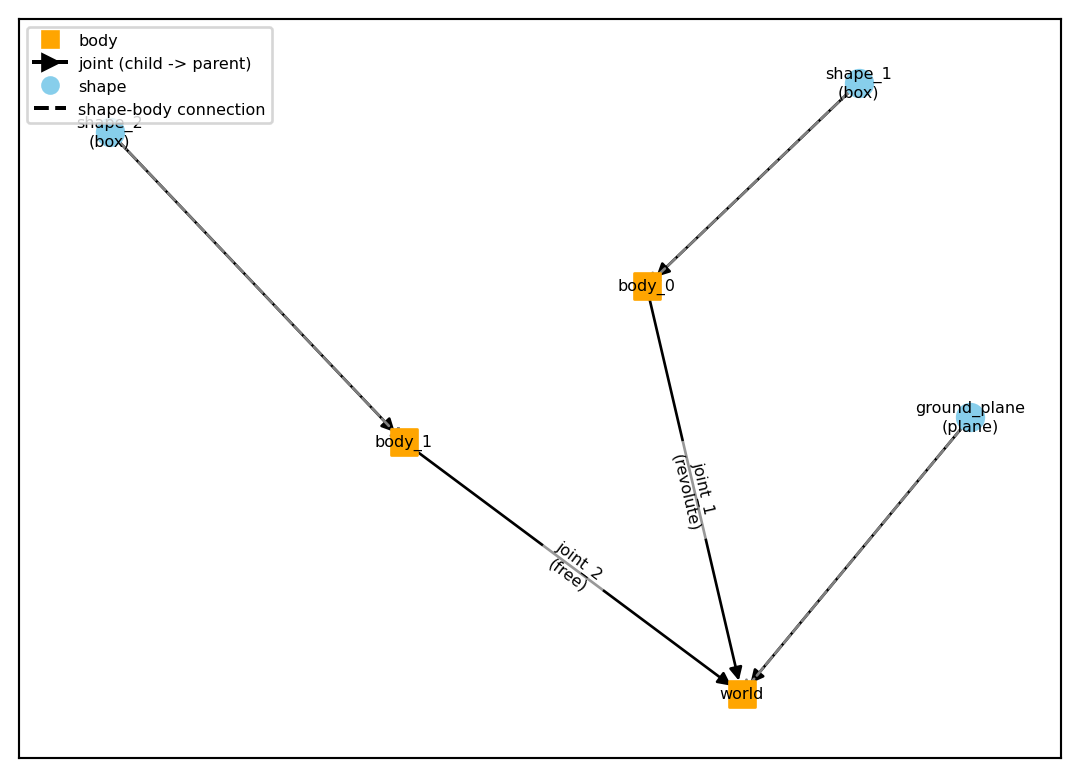

In [9]:
builder.plot_articulation()

In [10]:
builder = newton.ModelBuilder()
builder.add_ground_plane()

# Revolute body
xform = wp.transform(p=wp.vec3(0.0, -1.0, 1.0))
body = builder.add_link()
joint = builder.add_joint_revolute(
    parent=-1,
    child=body,
    parent_xform=xform,
    axis=wp.vec3(0.0, 0.0, 1.0),
    actuator_mode=newton.JointTargetMode.VELOCITY,
    target_kd=100,
)
builder.add_articulation([joint])
builder.add_shape_box(body)

model = builder.finalize()

state_0 = model.state()
state_1 = model.state()
control = model.control()
contacts = model.contacts()

solver = newton.solvers.SolverMuJoCo(model)

joint_target_vels = np.zeros(control.joint_target_vel.shape, dtype=np.float32)  # type: ignore
joint_index = builder.joint_qd_start[joint]
joint_target_vels[joint_index] = 8.0
control.joint_target_vel.assign(joint_target_vels)  # type: ignore

sim_time = 0.0

# viewer = create_viewer("spinning_cube", model)
viewer = create_viewer_viser("spinning_cube", model, quiet=False, overwrite=False)


vels = []

for step in trange(400):
    for substep in range(SIM_SUBSTEPS):
        state_0.clear_forces()
        model.collide(state_0, contacts)
        solver.step(state_0, state_1, control, contacts, TIME_STEP)
        state_0, state_1 = state_1, state_0

    viewer.begin_frame(sim_time)
    viewer.log_state(state_0)
    viewer.end_frame()

    vels.append(state_0.joint_qd.numpy().copy())  # type: ignore

    sim_time += FRAME_STEP

viewer.show_notebook()

Recording to docs/_static/spinning_cube_02.viser...


╭────── viser (listening *:8083) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8083   │
│   Websocket │ ws://localhost:8083     │
│             ╵                         │
╰───────────────────────────────────────╯

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 2/400 [00:00<00:21, 18.88it/s]

  4%|▍         | 16/400 [00:00<00:04, 86.44it/s]

...

 88%|████████▊ | 352/400 [00:02<00:00, 138.20it/s]

 92%|█████████▏| 366/400 [00:02<00:00, 138.24it/s]

 95%|█████████▌| 380/400 [00:02<00:00, 138.72it/s]

 98%|█████████▊| 394/400 [00:02<00:00, 138.93it/s]

100%|██████████| 400/400 [00:02<00:00, 133.78it/s]

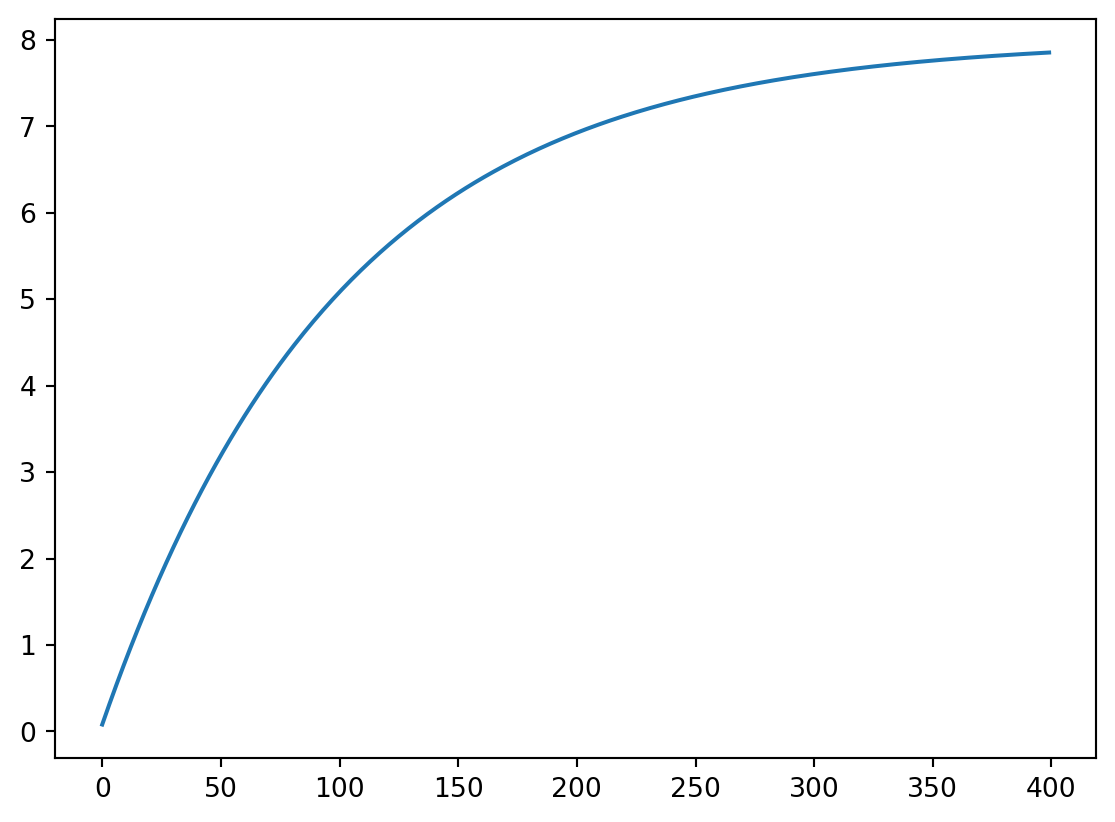

In [11]:
plt.plot(vels);